# 01. 결정트리

- 배우는 이유
  - 결정트리는 조건 분기로 분류하는 과정을 눈으로 볼 수 있어 모델의 판단 흐름을 설명하기 좋음.
  - 직선 하나로 나누기 어려운 비선형 관계도 여러 조건 조합으로 표현할 수 있음.
  - RandomForest, Gradient Boosting, XGBoost, LightGBM 같은 트리 기반 앙상블 모델의 기본 구조이므로 먼저 배움.

- 어디서 사용하는가?
  - 고객 이탈 여부, 대출 승인 여부, 불량품 여부, 질병 양성/음성 같은 분류 문제.
  - 모델이 어떤 조건으로 판단했는지 설명해야 하는 업무.
  - 앙상블 모델을 배우기 전 기본 트리 구조를 이해하는 기반.

### 01-01. 결정트리란?
- 결정트리는 조건을 반복해서 데이터를 나누는 분류 모델
- 스무고개처럼 질문을 하나씩 던지며 최종 클래스를 결정
- 예: `sugar <= 3.74`이면 왼쪽, 아니면 오른쪽으로 이동

### 01-02. 트리 구조 용어
- `root node`
  - 맨 처음 시작하는 노드
  - 전체 데이터가 처음 들어가는 지점

- `node`
  - 조건을 기준으로 데이터를 나누는 지점
  - 예: `alcohol <= 0.52`

- `branch`
  - 조건 결과에 따라 이동하는 경로
  - 보통 True/False 방향으로 갈라짐

- `leaf node`
  - 더 이상 나누지 않고 최종 예측을 내리는 노드
  - 분류에서는 leaf의 다수 클래스가 예측 결과가 됨

- `depth`
  - root에서 leaf까지 내려간 깊이
  - 깊이가 깊을수록 규칙이 복잡해짐

### 01-03. 결정트리의 장점
- 조건 분기 구조라서 설명이 쉬움
- feature 스케일 차이에 비교적 둔감
- 비선형 관계도 조건 조합으로 표현 가능
- 학습 결과를 그림으로 확인 가능

### 01-04. 결정트리의 단점
- 트리가 너무 깊으면 과적합되기 쉬움
- 데이터가 조금만 바뀌어도 분기 구조가 달라질 수 있음
- 단일 트리보다 RandomForest, Gradient Boosting 같은 앙상블에서 더 강력하게 활용됨

### 01-05. 하이퍼파라미터
- `criterion`
  - 어떤 기준으로 데이터를 나눌지 결정
  - 대표값: `gini`, `entropy`

- `max_depth`
  - 트리의 최대 깊이 제한
  - 작게 설정하면 단순한 트리, 크게 설정하면 복잡한 트리

- `min_samples_split`
  - 노드를 추가로 나누기 위해 필요한 최소 샘플 수
  - 크게 설정할수록 분기가 덜 일어남

- `min_samples_leaf`
  - leaf node에 있어야 하는 최소 샘플 수
  - 크게 설정할수록 너무 작은 leaf 생성을 막음

## 02. 실습 환경 준비

- `DecisionTreeClassifier`: 조건을 반복해서 데이터를 나누고 클래스를 예측하는 결정트리 분류 모델
- `plot_tree`: 학습된 트리 구조를 그림으로 확인하는 함수
- `GridSearchCV`: 여러 하이퍼파라미터 후보를 교차검증으로 비교하는 도구

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier: 조건 분기로 클래스를 예측하는 결정트리 분류 모델임.
# plot_tree: 학습된 트리 구조를 그림으로 보여주는 함수임.
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 03. 데이터 로드

- 사용 데이터: 결정트리 수업용 와인 샘플 데이터
- 목표: 와인의 화학적 특성을 보고 레드와인/화이트와인 분류
- target 컬럼: `class`
  - `0`: red
  - `1`: white

### 데이터 구성 의도
- 실제 와인 데이터의 일부를 그대로 가져온 데이터가 아니라, 결정트리 설명을 위해 만든 수업용 샘플 데이터
- `sugar`, `pH`, `alcohol` 조건을 조합해야 분류가 잘 되도록 구성
- 일부 예외 샘플을 섞어 기본 트리가 너무 깊어지고, 가지치기 효과가 보이도록 구성

In [2]:
# class 0은 red, class 1은 white를 의미함.
wine_df = pd.read_csv('data/wine_simple.csv')

display(wine_df.head())

print('데이터 크기:', wine_df.shape)
print()

# value_counts(): class별 데이터 개수를 확인함.
# 클래스 개수가 비슷하면 accuracy를 해석하기 쉬움.
print('class 분포')
print(wine_df['class'].value_counts().sort_index())
print()

# groupby(): class별 feature 평균을 확인함.
# red와 white가 어느 정도 다른 분포를 가지는지 확인함.
display(
    wine_df
    .groupby('class')[['alcohol', 'sugar', 'pH']]
    .agg(['mean', 'min', 'max'])
    .round(2)
)

,alcohol,sugar,pH,class
0,11.87,5.36,3.49,1
1,12.52,1.25,3.56,0
2,11.87,1.81,2.97,1
3,12.34,8.32,3.23,1
4,9.80,6.91,3.14,0


데이터 크기: (266, 4)

class 분포
class
0    133
1    133
Name: count, dtype: int64



alcohol              sugar                pH           
         mean   min    max  mean   min   max  mean  min   max
class                                                        
0       10.39  8.69  12.68  3.35  1.23  8.29  3.31  2.9  3.59
1       10.90  8.87  12.77  5.77  1.33  8.39  3.20  2.9  3.60

## 04. 학습/평가 데이터 분리

- 결정트리는 feature의 크기를 거리나 회귀계수처럼 직접 비교하는 모델이 아님.
- 따라서 KNN, SVM, 선형 모델과 달리 스케일링이 필수는 아님.
- 예를 들어 `sugar <= 3.74`처럼 나오면 원래 당도 기준으로 해석할 수 있음.

In [3]:
X = wine_df.drop('class', axis=1) # 도수, 당도, 산도
y = wine_df['class'] # 0(red), 1(white)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(212, 3) (212,)
(54, 3) (54,)


## 05. 기본 결정트리 분류 모델 학습

### `DecisionTreeClassifier`
- 조건 분기를 반복해 클래스를 예측하는 모델
- 각 노드는 불순도를 줄이는 방향으로 feature와 기준값을 선택
- leaf node에 도착하면 해당 leaf의 다수 클래스로 예측

### 기본 트리를 먼저 보는 이유
- 제한을 주지 않은 결정트리는 훈련 데이터를 끝까지 세밀하게 나누려는 경향이 있음
- 예외 샘플까지 외우면 학습셋 점수는 높지만 평가셋 점수는 낮아질 수 있음
- 이 상태를 확인한 뒤 가지치기로 복잡도를 줄여 비교함

### `score()`
- 분류 모델의 `score()` 기본값은 accuracy(정확도)
- accuracy는 전체 데이터 중 맞힌 비율
- 학습셋 점수와 평가셋 점수를 함께 비교해야 함

In [5]:
dt_clf = DecisionTreeClassifier(random_state=42)


dt_clf.fit(X_train, y_train) # 학습

# 평가
print("학습셋:", dt_clf.score(X_train, y_train))
print("평가셋:", dt_clf.score(X_test, y_test))

print("트리의 깊이: ", dt_clf.get_depth())
print("리프노드 개수: ", dt_clf.get_n_leaves())

학습셋: 1.0
평가셋: 0.7962962962962963
트리의 깊이:  10
리프노드 개수:  39


## 06. 트리 시각화 준비

### Graphviz와 plot_tree
- 결정트리는 그림으로 보면 구조를 이해하기 쉬움
- `plot_tree()`는 scikit-learn에서 제공하는 기본 트리 시각화 함수
- Graphviz는 더 정교한 트리 그림을 만들 때 사용할 수 있는 도구

In [6]:
# !pip install graphviz pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=ba6d61e3a7b20fdaa87515eec8e32a05ab54c6a4424971c8a7f71c6e418b383f
  Stored in directory: c:\users\playdata2\appdata\local\pip\cache\wheels\77\54\7c\c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus

   -------------------- ------------------- 1/2 [graphviz]
   -------------------- ------------------- 1/2 [graphviz]
   -------------------- ------------------- 1/2 [graphviz]
   -------------------- ------------------- 1/2 [graphviz]
   -------------------- ------------------- 1/2 [graphviz]
   ---------------------------------------- 2/2 [graphvi

## 07. 트리 그림 읽는 법

### 07-01. 트리 그림에서 볼 것
- 조건: 데이터를 왼쪽/오른쪽으로 나누는 기준
- `gini`: 현재 노드의 불순도
- `samples`: 현재 노드에 들어온 데이터 개수
- `value`: 클래스별 데이터 개수
- `class`: 현재 노드에서 예측하는 대표 클래스

### 07-02. 설명 예시
- 조건이 True이면 왼쪽 가지로 이동
- 조건이 False이면 오른쪽 가지로 이동
- leaf에 가까워질수록 특정 클래스 비율이 높아지는지 확인

### 07-03. 기준값 해석
- 이 노트북은 스케일링하지 않은 feature로 트리를 학습함.
- 따라서 `sugar <= 3.74` 같은 기준값은 원래 데이터의 당도 단위로 해석할 수 있음.

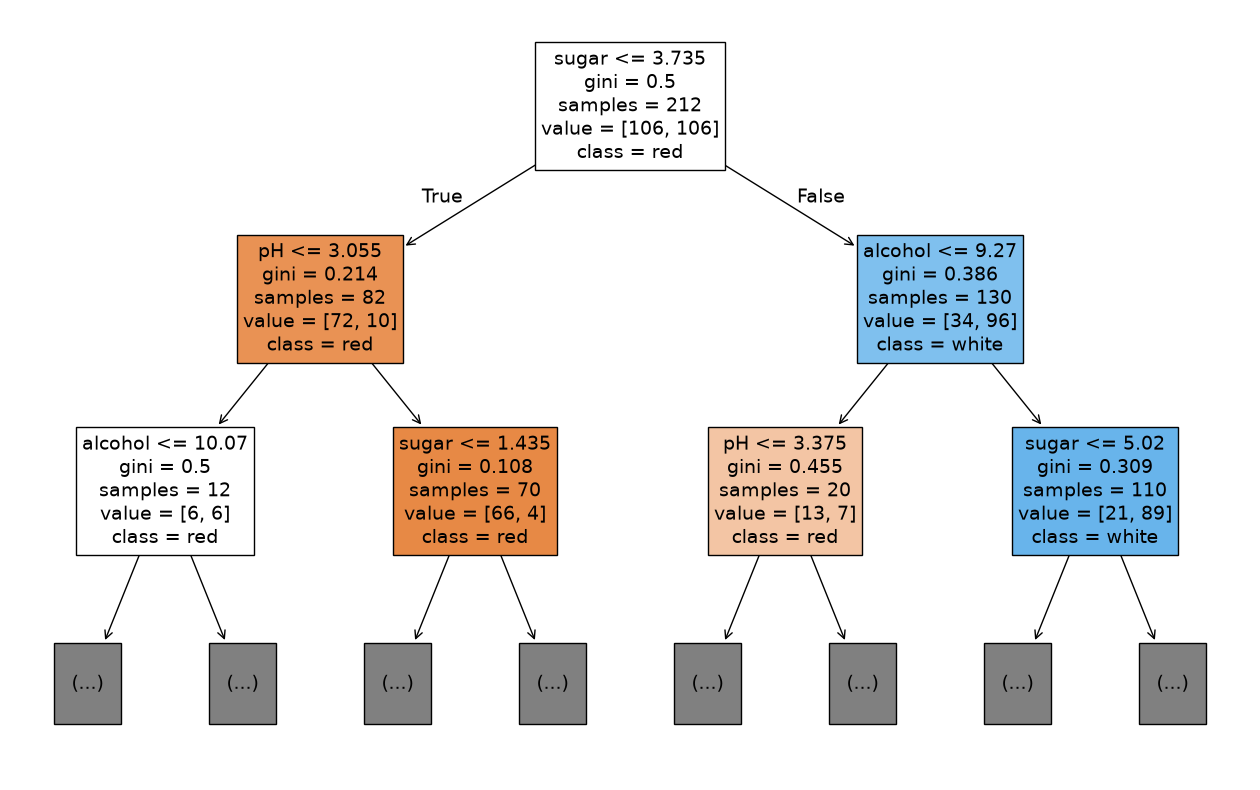

In [12]:
plt.figure(figsize=(16, 10))

# plot_tree(): 결정트리의 조건, 불순도, 샘플 수, 클래스 분포를 시각화함.
# max_depth=2: 그림이 너무 복잡해지지 않도록 상위 2단계까지만 표시함.
plot_tree(
    dt_clf,
    max_depth=2,
    filled=True,
    feature_names=X.columns,
    class_names=['red', 'white'],
    fontsize=14,
)

plt.savefig('dt_tree_wine.png', dpi=1200, bbox_inches='tight')
plt.show()

## 08. 정보이득과 불순도

### 08-01. 불순도(Impurity)
- 한 노드 안에 여러 클래스가 얼마나 섞여 있는지 나타내는 값
- 한 클래스만 있으면 불순도 낮음
- 여러 클래스가 비슷하게 섞여 있으면 불순도 높음

### 08-02. 정보이득(Information Gain)
- 분할 전보다 분할 후 불순도가 얼마나 줄었는지 나타내는 값
- 결정트리는 정보이득이 큰 분할을 선호
- 쉽게 말하면 “나눴을 때 더 깔끔하게 분리되는 질문”을 찾는 과정

### 08-03. `criterion`
- 불순도를 계산하는 기준
- `gini`: 지니 불순도 사용
- `entropy`: 엔트로피 사용
- 둘 다 데이터를 더 순수한 그룹으로 나누기 위한 기준


### 08-04. 지니 불순도(Gini Impurity)

- 지니 불순도는 노드 안의 클래스가 얼마나 섞여 있는지 측정
- 값이 낮을수록 한 클래스가 많이 모여 있음
- 값이 높을수록 여러 클래스가 섞여 있음

```text
Gini = 1 - (클래스1 비율^2 + 클래스2 비율^2 + ... + 클래스n 비율^2)
```

수식으로 쓰면 다음과 같음.

```text
Gini = 1 - Σ(pk^2)
```

- `pk`: 해당 노드에서 k번째 클래스가 차지하는 비율
- 이진분류에서도 다중분류에서도 같은 방식으로 계산
- `Gini = 0`이면 한 클래스만 있는 매우 순수한 노드
- 클래스가 섞일수록 Gini 값 증가


### 08-05. 지니 불순도 계산 예시

지니 불순도는 한 노드 안에 클래스가 얼마나 섞여 있는지 보는 값임.
클래스 분포가 달라질 때 지니 불순도 값이 어떻게 바뀌는지 확인함.

확인 포인트:
- 클래스가 반반 섞이면 지니 불순도가 높음
- 한 클래스 비율이 커질수록 지니 불순도가 낮아짐
- 한 클래스만 있으면 지니 불순도가 0이 됨

In [14]:
# 클래스별 개수를 받아 지니 불순도를 계산하는 함수
def gini_impurity(counts):
    count = np.array(counts)
    probabilities = count / count.sum()
    return 1 - np.sum(probabilities**2)

gini_examples = pd.DataFrame([
    {'node': 'red 50 / white 50', 'counts': [50, 50]},
    {'node': 'red 90 / white 10', 'counts': [90, 10]},
    {'node': 'red 100 / white 0', 'counts': [100, 0]},
])

gini_examples['gini'] = gini_examples['counts'].apply(gini_impurity)
gini_examples

,node,counts,gini
0,red 50 / white 50,"[50, 50]",0.50
1,red 90 / white 10,"[90, 10]",0.18
2,red 100 / white 0,"[100, 0]",0.00


### 08-06. 엔트로피(Entropy)

- 엔트로피도 노드 안의 클래스가 얼마나 섞여 있는지 측정하는 지표
- 불확실성 또는 혼잡도를 나타냄
- 한 클래스만 있으면 엔트로피 낮음
- 여러 클래스가 비슷하게 섞이면 엔트로피 높음

```text
Entropy = -Σ(pk * log2(pk))
```

- `pk`: 해당 노드에서 k번째 클래스가 차지하는 비율
- `log2`: 밑이 2인 로그


- `gini`와 `entropy` 모두 좋은 분할을 찾기 위한 기준
- 일반적으로 결과가 크게 다르지 않은 경우가 많음
- 실무에서는 기본값인 `gini`를 먼저 사용하고, 필요하면 비교


## 09. Entropy 기준 결정트리 학습

- `criterion='entropy'`로 분할 기준을 바꿔 모델을 학습함.
- `max_depth=5`로 트리 깊이 제한을 걸어둠.
- 이 수업용 데이터는 예외 샘플이 섞여 있어 `gini`와 `entropy`의 트리 구조나 점수가 다르게 나올 수 있음.

**포인트**
- `criterion`은 불순도를 계산하는 기준임.
- 같은 데이터라도 기준이 바뀌면 선택되는 분할 순서가 달라질 수 있음.
- 성능 차이만 보지 말고 트리 깊이, leaf 개수, 분기 조건도 함께 비교함.

In [15]:
# 엔트로피를 이용하여 불순도를 계산
wine_dt_clf_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42,
)
wine_dt_clf_entropy.fit(X_train, y_train)

# 지니를 이용해서 불순도 계산
wine_dt_clf_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42,
)
wine_dt_clf_gini.fit(X_train, y_train)

criterion_result_df = pd.DataFrame([
    {
        'criterion': 'gini',
        'train_accuracy': wine_dt_clf_gini.score(X_train, y_train),
        'test_accuracy': wine_dt_clf_gini.score(X_test, y_test),
        'tree_depth': wine_dt_clf_gini.get_depth(),
        'leaf_count': wine_dt_clf_gini.get_n_leaves()
    },
    {
        'criterion': 'entropy',
        'train_accuracy': wine_dt_clf_entropy.score(X_train, y_train),
        'test_accuracy': wine_dt_clf_entropy.score(X_test, y_test),
        'tree_depth': wine_dt_clf_entropy.get_depth(),
        'leaf_count': wine_dt_clf_entropy.get_n_leaves()
    }
]).round(4)

display(criterion_result_df)


,criterion,train_accuracy,test_accuracy,tree_depth,leaf_count
0,gini,0.9387,0.8889,5,23
1,entropy,0.9245,0.9074,5,21


## 09-03. Entropy 트리 시각화

- 앞에서 학습한 entropy 기준 트리를 그림으로 확인
- `max_depth=3`까지만 보여주어 상위 분기 구조를 읽기 쉽게 제한
- gini 기준 트리와 첫 분기 또는 하위 분기가 어떻게 다른지 비교

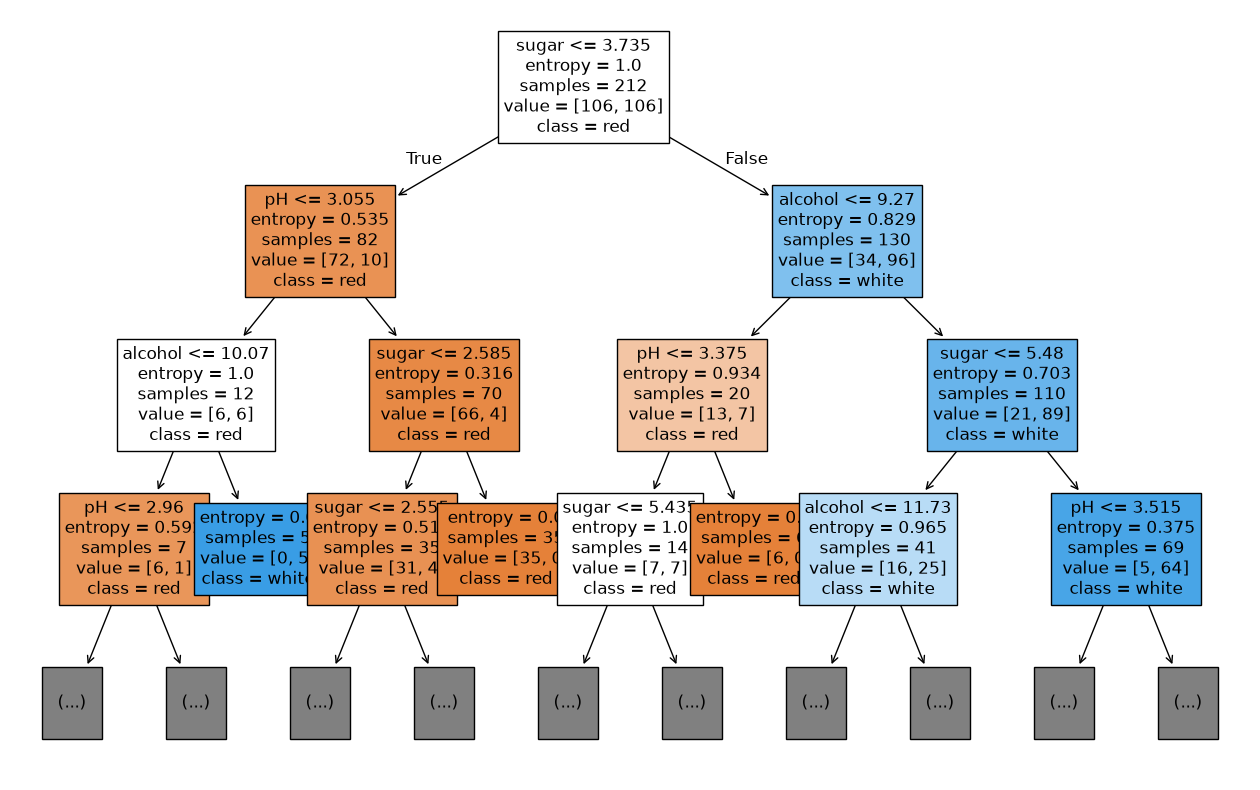

In [17]:
plt.figure(figsize=(16, 10))
plot_tree(
    wine_dt_clf_entropy,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['red', 'white'],
    fontsize=12
)
plt.savefig('dt_tree_wine_by_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

# criterion 종류에 따라 트리으 분기 구조나 leaf node 분포가 달라질 수 있다.

## 10. 가지치기(Pruning)

### 10-01. 가지치기란?
- 결정트리가 너무 깊고 복잡해지는 것을 막는 방법
- 훈련 데이터를 과하게 외우는 과적합을 줄이기 위해 사용

### 10-02. 사전 가지치기
- 트리가 자라기 전에 미리 제한을 거는 방식
- 대표 파라미터
  - `max_depth`
  - `min_samples_split`
  - `min_samples_leaf`

### 10-03. 사후 가지치기
- 트리를 먼저 만든 뒤 불필요한 가지를 제거하는 방식
- scikit-learn에서는 `ccp_alpha`로 비용 복잡도 가지치기 가능

## 10-04. `max_depth`로 가지치기

- `max_depth`: 트리의 최대 깊이 제한
- 값이 작을수록 트리가 단순해짐
- 값이 클수록 더 많은 조건을 만들 수 있음

비교할 값:
- `None`: 깊이 제한 없음
- `1`, `3`, `5`: 최대 깊이를 제한

확인 포인트:
- 제한 없는 트리는 학습셋을 거의 완벽하게 맞출 수 있음.
- 하지만 평가셋 점수가 더 낮으면 예외 샘플까지 외운 과적합으로 볼 수 있음.
- 적절한 깊이 제한은 트리 구조를 단순하게 만들고 평가 성능을 개선할 수 있음.

In [18]:
max_depth_options = [None, 1, 3, 5]
wine_depth_models = {}
depth_result = []

for max_depth in max_depth_options:
    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=max_depth,
    )

    model.fit(X_train, y_train)

    wine_depth_models[max_depth] = model

    depth_result.append({
        'max_depth': 'None' if  max_depth is None else max_depth,
        'train_accuracy': model.score(X_train, y_train),
        'test_accuracy': model.score(X_test, y_test),
        'tree_depth': model.get_depth(),
        'leaf_count': model.get_n_leaves()
    })

depth_result_df = pd.DataFrame(depth_result).round(4)
display(depth_result_df)

,max_depth,train_accuracy,test_accuracy,tree_depth,leaf_count
0,None,1.0000,0.7963,10,39
1,1,0.7925,0.7963,1,2
2,3,0.8443,0.8519,3,8
3,5,0.9387,0.8889,5,23


## 10-05. `min_samples_split`으로 가지치기

- `min_samples_split`: 노드를 다시 나누기 위해 필요한 최소 샘플 수
- 값이 작으면 작은 노드도 계속 나눌 수 있음
- 값이 크면 충분히 많은 데이터가 있는 노드만 나눔

비교할 값:
- `2`: 기본값
- `20`, `40`, `130`: 분할 조건을 점점 엄격하게 적용

해석 포인트:
- 값을 키우면 leaf 개수가 줄어들어 트리가 단순해짐.
- 너무 크게 잡으면 필요한 분할까지 막혀 과소적합이 될 수 있음.

## 10-06. 가지치기된 트리 시각화

- `max_depth=5`를 적용한 트리 구조 확인
- 제한 없는 트리보다 leaf 개수가 줄어들어 해석이 쉬워짐
- 그림에서는 상위 3단계까지만 보여주어 핵심 분기 조건에 집중

## 10-07. `min_samples_leaf`로 가지치기

- `min_samples_leaf`: leaf node에 있어야 하는 최소 샘플 수
- leaf에 너무 적은 데이터만 남는 것을 막음
- 작은 데이터 조각이나 예외 샘플에 과하게 맞추는 현상을 줄일 수 있음

비교할 값:
- `1`: 기본값
- `5`, `10`, `20`: leaf에 필요한 최소 샘플 수를 점점 크게 설정

해석 포인트:
- 적절한 값은 과적합을 줄일 수 있음.
- 너무 큰 값은 필요한 분할까지 막아 과소적합을 만들 수 있음.

## 11. 특성 중요도(Feature Importance)

### 11-01. 특성 중요도란?
- 트리가 분기할 때 불순도 감소에 많이 기여한 feature의 중요도
- 값이 클수록 모델이 해당 feature를 분류에 많이 사용했다는 뜻

### 11-02. 주의할 점
- 중요도가 높다고 반드시 원인이라는 뜻은 아님
- feature 간 상관관계가 있으면 중요도가 한쪽 feature에 몰릴 수 있음
- 모델 해석의 출발점으로 사용하고, 인과관계로 단정하지 않음


## 11-03. 특성 중요도 배열 확인

- `feature_importances_`는 feature별 중요도를 배열로 반환함.
- 컬럼명과 함께 봐야 어떤 feature가 중요한지 해석할 수 있음.
- 여기서는 다시 기본 결정트리 모델을 학습해 특성 중요도를 확인함.
- 중요도는 이 모델이 분기할 때 어떤 feature를 많이 사용했는지를 나타냄.


## 11-04. 특성 중요도 시각화

- 막대그래프로 feature 중요도를 확인
- 어떤 feature가 모델 판단에 많이 쓰였는지 한눈에 비교
- 설명할 때는 “중요하다”보다 “이 모델이 많이 사용했다”라고 말하는 것이 안전


## 12. 실습 - iris 결정트리 분류

### 12-01. 실습 목표
- iris 데이터로 결정트리 분류 흐름을 직접 반복
- 데이터 로드, 학습/평가 분리, 모델 학습, 시각화, 특성 중요도 확인

### 12-02. 수행 순서
1. iris 데이터 로드
2. feature와 target 분리
3. 학습/평가 데이터 분리
4. 결정트리 모델 학습
5. 트리 시각화
6. 가장 중요한 feature 확인


## 12-04. iris 데이터 분리

- `load_iris(as_frame=True)`로 내장 데이터를 DataFrame 형태로 로드함.
- `iris.data`: feature
- `iris.target`: 정답 클래스
- `stratify=y`로 클래스 비율 유지

주의:
- 결정트리는 스케일링이 필수는 아님.
- 이 실습에서도 트리 조건을 원래 단위로 읽기 위해 스케일링하지 않음.


## 12-05. iris 결정트리 학습

- `max_depth=3`으로 트리 깊이 제한
- iris 데이터는 구조가 단순해 작은 깊이로도 좋은 성능이 나올 수 있음
- 학습셋과 평가셋 점수를 비교해 과적합 여부 확인


## 12-06. 하이퍼파라미터 튜닝

### 12-06-01. `GridSearchCV`
- 여러 하이퍼파라미터 후보를 모두 조합해 비교하는 도구
- 교차검증으로 평균 성능을 계산한 뒤 가장 좋은 조합 선택

### 12-06-02. 후보 파라미터
- `criterion`: `gini`, `entropy`
- `max_depth`: 트리 최대 깊이
- `min_samples_split`: 분할을 위한 최소 샘플 수
- `min_samples_leaf`: leaf의 최소 샘플 수

### 12-06-03. 실행 안정성
- 수업 환경에서는 병렬 실행이 막히는 경우가 있음.
- 그래서 `n_jobs=1`로 설정해 한 프로세스에서 안정적으로 실행함.


## 12-07. iris 트리 시각화

- GridSearchCV가 선택한 `iris_best_model`의 트리 구조를 그림으로 확인함.
- 상위 분기에서 어떤 feature가 중요한 역할을 하는지 확인함.
- leaf node에서 최종 클래스가 어떻게 결정되는지 읽음.


## 12-08. iris 특성 중요도 확인

- iris feature 중 모델이 많이 사용한 feature 확인
- 그래프를 보고 “모델이 어떤 기준으로 품종을 구분했는지” 설명
- 중요도가 높은 feature가 실제 생물학적 원인이라는 뜻은 아니며, 모델의 분기 기준으로 해석
